## Baseline model

In [120]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import joblib


In [121]:
RANDOM_STATE = 42
%matplotlib inline
warnings.filterwarnings("ignore")

In [122]:
df = pd.read_csv('../../data/preprocessed.csv')
df.sample(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
20746,519,France,Male,33,1,0.00,1,1,0,139919.38,0
38081,667,France,Female,27,5,161884.99,1,1,1,9617.24,0
83136,643,Germany,Male,35,5,144893.07,1,1,0,51703.09,0
101753,676,France,Male,48,4,0.00,1,1,1,173425.68,1
8356,714,Spain,Male,34,5,0.00,2,1,1,131736.23,0


### 1. Линейные модели классификации

#### 1.1 Кодирование категориальных признаков

к колонкам `Gender`, `Geography` с малым количеством категорий применим в пайплайне One-Hot-Encoding

In [123]:
print(df['Gender'].value_counts())
print(df['Geography'].value_counts())

X, y = df.drop(columns='Exited'), df['Exited']
print(X.describe())

num_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Tenure']
ohe_features = ['Gender', 'Geography']
ohe = OneHotEncoder(drop='first', handle_unknown='ignore')

Gender
Male      93150
Female    71884
Name: count, dtype: int64
Geography
France     94215
Spain      36213
Germany    34606
Name: count, dtype: int64
         CreditScore            Age         Tenure        Balance  \
count  165034.000000  165034.000000  165034.000000  165034.000000   
mean      656.454373      38.125883       5.020353   55478.086689   
std        80.103340       8.867207       2.806159   62817.663278   
min       350.000000      18.000000       0.000000       0.000000   
25%       597.000000      32.000000       3.000000       0.000000   
50%       659.000000      37.000000       5.000000       0.000000   
75%       710.000000      42.000000       7.000000  119939.517500   
max       850.000000      92.000000      10.000000  250898.090000   

       NumOfProducts      HasCrCard  IsActiveMember  EstimatedSalary  
count  165034.000000  165034.000000   165034.000000    165034.000000  
mean        1.554455       0.753954        0.497770    112574.822734  
std         0

In [124]:
preprocessor = ColumnTransformer(
    transformers=[
        ('categ', ohe, ohe_features),
        ('num', StandardScaler(), num_cols)
    ], remainder='passthrough'
)

#### 1.2 Пайплайн обучения модели с учетом дисбаланса классов

In [125]:
print(f"Баланс классов: {y.value_counts(normalize=True)}")
# для честной оценки модели: не устраняет дисбаланс, а сохраняет его пропорцию в каждом фолде
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000,
                               random_state=RANDOM_STATE,
                               class_weight='balanced'  # автоматически взвешивать классы
                               ))
])
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE, stratify=y)
pipeline.fit(X_train, y_train)

Баланс классов: Exited
0    0.788401
1    0.211599
Name: proportion, dtype: float64


,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categ', ...), ('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### 1.3 Выбор метрики качества моделей

Accuracy (доля верных ответов) - очень плохой выбор для оценки моделей при дисбалансе классов. 
Рассмотрим другие метрики. Будем учитывать, что в нашей бизнес-задаче важнее не допустить оттока клиентов (class 1 - доля в таргете 21%).

* Precision (точность) - какая доля из помеченных уходящими действительно уйдёт. Второстепенная метрика 
* Recall (полнота) - какую долю модель выявила из реально уходящих. Важная метрика
* F-1 мера - усредненная метрика по точности и полноте. Подходит для несбалансированных данных
* ROC-AUC - интегральная метрика, не требует подбора порога для каждой модели. Хороша для подбора модели
* PR-AUC - также интегральная метрика. При сильном дисбалансе более информативна, показывает, насколько хорошо модель находит редкий класс

##### Итоги: 
При подборе гиперпараметров в `GridSearch` будем использовать `recall`, но видеть и PR-AUC(scoring=`average_precision`). В classification_report обращаем внимание на 1 класс.

In [126]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"\nPR-AUC: {average_precision_score(y_test, y_proba):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.76      0.83     32529
           1       0.45      0.73      0.56      8730

    accuracy                           0.75     41259
   macro avg       0.68      0.75      0.69     41259
weighted avg       0.82      0.75      0.77     41259


PR-AUC: 0.5706


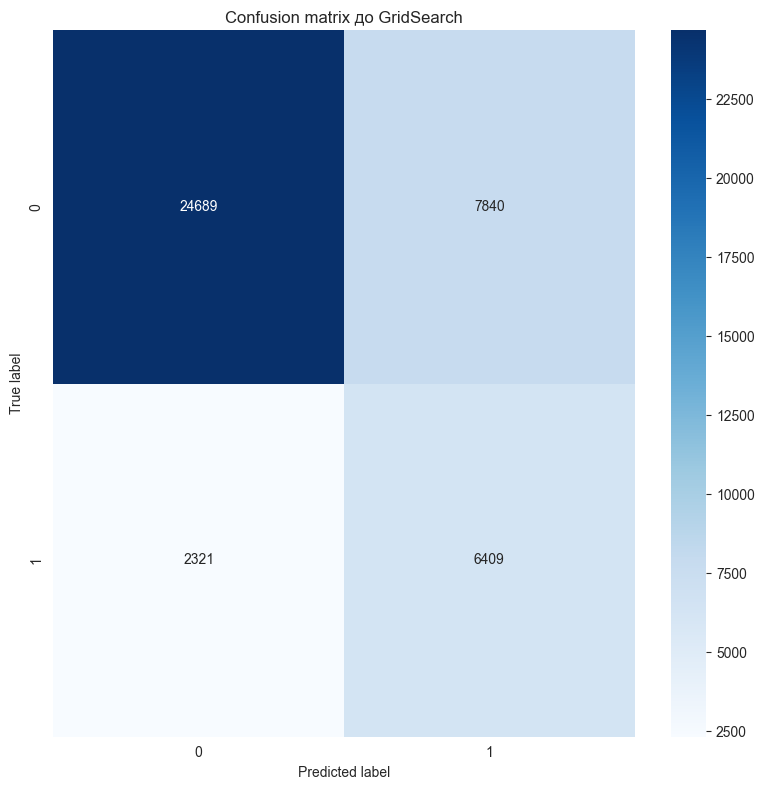

In [127]:
def plot_confusion_matrix(y_test, y_pred,
                          pipeline_name,
                          figsize=(8, 8), cmap="Blues"):
    """Строит и показывает матрицу ошибок."""
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap)
    plt.title(f"Confusion matrix {pipeline_name}")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(y_test, y_pred, "до GridSearch")

#### Выводы:
recall 1 класса ~ 0.73 

precision 1 класса ~ 0.45

PR_AUC ~ 0.57

FN 2321 Модель пропускает  (~27%) уходящих клиентов

#### 1.4 Подбор гиперпараметров модели логистической регрессии

In [128]:
param_grid = {
    'clf__C': np.logspace(-2, 2, 7),
    'clf__class_weight': ['balanced', {0: 1, 1: 5}],
    'clf__l1_ratio': np.linspace(0.1, 1.0, 7),
    'clf__penalty': ['elasticnet'],  # для будущего PolynomialFeatures
    'clf__solver': ['saga'],  # для будущего PolynomialFeatures
}
grid = GridSearchCV(pipeline,
                    param_grid,
                    cv=skf,
                    scoring={
                        'pr_auc': 'average_precision',
                        'recall': 'recall'  # Recall (по порогу 0.5)
                    },
                    refit='recall',
                    n_jobs=-1,
                    return_train_score=True,
                    )
grid.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'clf__C': array([1.0000...00000000e+02]), 'clf__class_weight': ['balanced', {0: 1, 1: 5}], 'clf__l1_ratio': array([0.1 , ..., 0.85, 1. ]), 'clf__penalty': ['elasticnet'], ...}"
,scoring,"{'pr_auc': 'average_precision', 'recall': 'recall'}"
,n_jobs,-1
,refit,'recall'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('categ', ...), ('num', ...)]"


In [129]:
best_model = grid.best_estimator_

y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:, 1]

print("Classification Report с подобранными гиперпараметрами:")
print(classification_report(y_test, y_pred_opt))

print(f"PR-AUC: {average_precision_score(y_test, y_proba_opt):.4f}")

print(f"\nЛучшие параметры: {grid.best_params_}")
print(f"Лучший Recall (по CV): {grid.best_score_:.4f}")

Classification Report с подобранными гиперпараметрами:
              precision    recall  f1-score   support

           0       0.93      0.68      0.78     32529
           1       0.40      0.80      0.53      8730

    accuracy                           0.70     41259
   macro avg       0.66      0.74      0.66     41259
weighted avg       0.81      0.70      0.73     41259

PR-AUC: 0.5676

Лучшие параметры: {'clf__C': np.float64(0.01), 'clf__class_weight': {0: 1, 1: 5}, 'clf__l1_ratio': np.float64(1.0), 'clf__penalty': 'elasticnet', 'clf__solver': 'saga'}
Лучший Recall (по CV): 0.8019


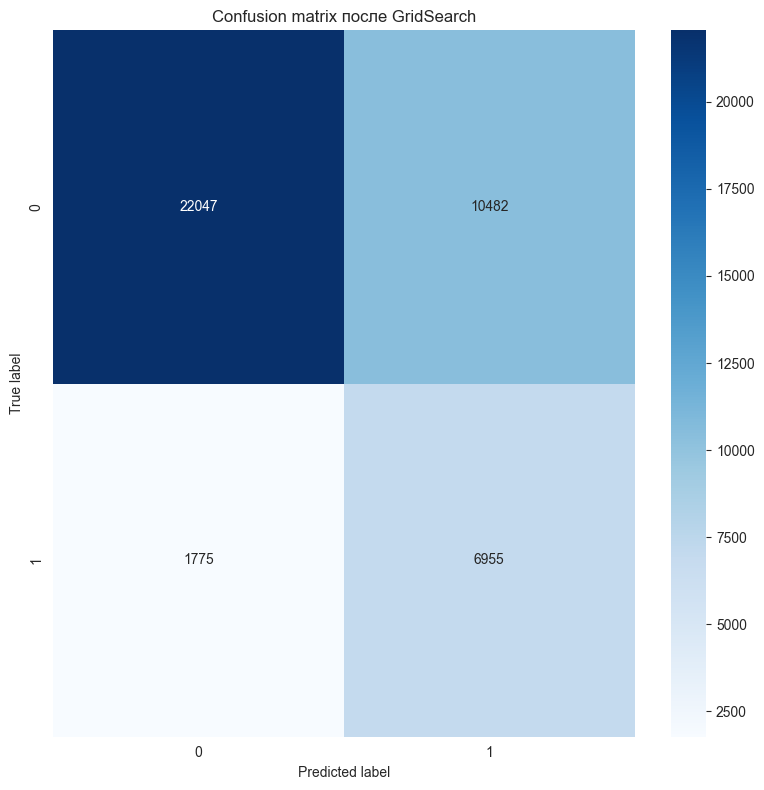

In [130]:
plot_confusion_matrix(y_test, y_pred_opt, "после GridSearch")

#### Выводы:
recall 1 класса ~ 0.80, выше на 7 п.п.

precision 1 класса ~ 0.40 немного уменьшился

PR_AUC ~ 0.57 почти не изменился

FN 1776 Модель пропускает меньше (~20%) уходящих клиентов. Сохраним параметры как Baseline

In [131]:
model_artifact = {
    "model": best_model,  # обученный пайплайн
    "best_params": grid.best_params_,  # дубликат для быстрого доступа
    "feature_names": X_train.columns.tolist(),  # критично для совпадения колонок
    "metrics": {
        "cv_recall": grid.best_score_,
        "test_pr_auc": average_precision_score(y_test, y_proba_opt)
    }
}

joblib.dump(model_artifact, "churn_model_artifact.pkl", compress=3)

['churn_model_artifact.pkl']

#### 1.5 Подбор оптимального порога

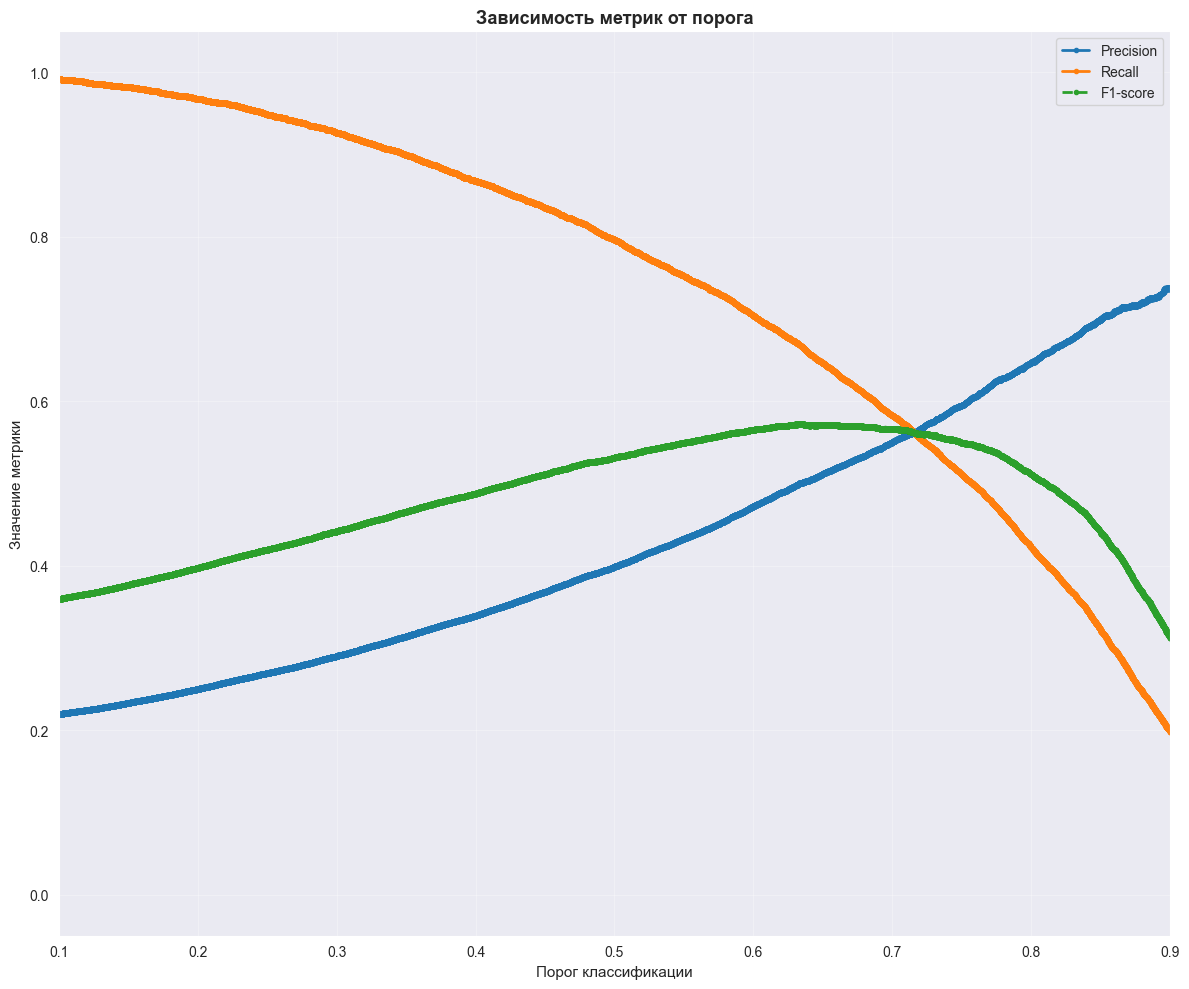

In [132]:
def plot_metrics_vs_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

    plt.figure(figsize=(12, 10))
    plt.plot(thresholds, precisions[:-1], label='Precision', marker='.', linewidth=2)
    plt.plot(thresholds, recalls[:-1], label='Recall', marker='.', linewidth=2)
    plt.plot(thresholds, f1_scores, label='F1-score', marker='.', linewidth=2, linestyle='--')

    plt.xlabel('Порог классификации', fontsize=11)
    plt.ylabel('Значение метрики', fontsize=11)
    plt.title('Зависимость метрик от порога', fontsize=13, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xlim([0.1, 0.9])
    plt.tight_layout()
    plt.show()


plot_metrics_vs_threshold(y_test, y_proba_opt)

In [133]:
threshold = 0.4

# Применяем кастомный порог
y_pred_custom = (y_proba_opt >= threshold)
print("Classification Report с подобранным порогом:")
print(classification_report(y_test, y_pred_custom))

Classification Report с подобранным порогом:
              precision    recall  f1-score   support

           0       0.94      0.55      0.69     32529
           1       0.34      0.87      0.49      8730

    accuracy                           0.61     41259
   macro avg       0.64      0.71      0.59     41259
weighted avg       0.81      0.61      0.65     41259



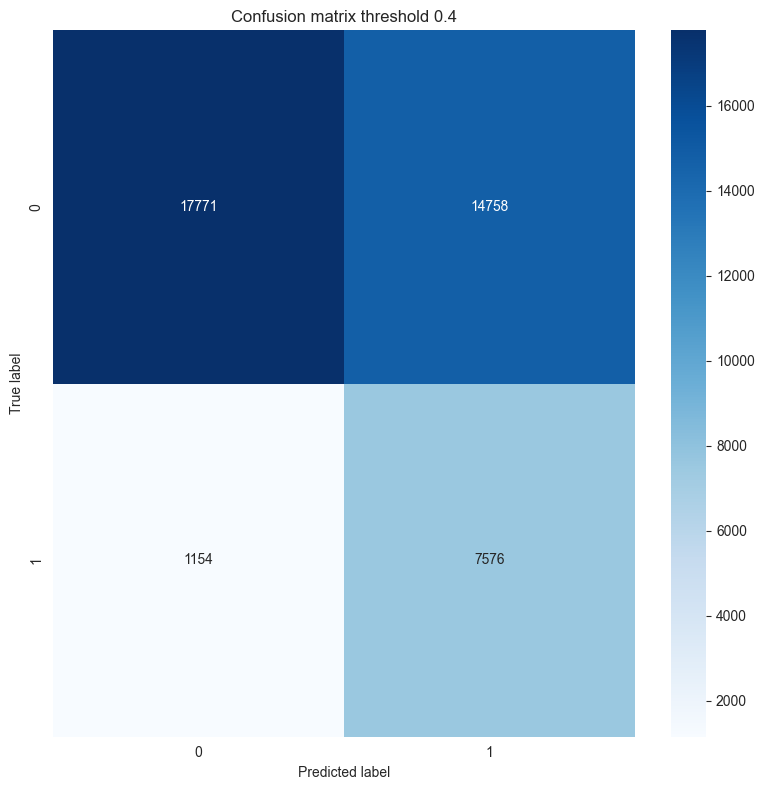

In [134]:
plot_confusion_matrix(y_test, y_pred_custom, f"threshold {threshold}")

#### Выводы:
При пороге классификации 0.4: 

recall 1 класса ~ 0.87   +7 п.п.

precision 1 класса ~ 0.34  -6 п.п.

FN 1154 Модель пропускает значительно меньше (~13%) уходящих клиентов. Но FP слишком велик (почти половина лояльных клиентов). В дальнейшем не будем использовать кастомный порог классов.

#### 1.6 Feature Engineering для логистической регрессии



#### PolynomialFeatures

In [147]:
preprocessor = ColumnTransformer([
    ('poly', Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False))
    ]), num_cols),
    ('categ', ohe, ohe_features),
], remainder='passthrough')

param_grid_pf = {
    'clf__C': np.logspace(-2, 2, 9),     
    'clf__l1_ratio': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0],  # добавили чистый Ridge (0.0)
    'clf__class_weight': ['balanced', {0: 1, 1: 4}, {0: 1, 1: 5}]
}

pf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])
grid_pf = GridSearchCV(
    pf_pipeline, 
    param_grid=param_grid_pf,
    scoring='recall', 
    cv=5, 
    n_jobs=-1,
    refit=True
)
grid_pf.fit(X_train, y_train)

print("Новые лучшие параметры:", grid_pf.best_params_)

y_proba_poly = grid_pf.predict_proba(X_test)[:, 1]
y_pred_poly = grid_pf.predict(X_test)

print("Report после добавления PolynomialFeatures:")
print(classification_report(y_test, y_pred_poly))
print(f"PR-AUC: {average_precision_score(y_test, y_proba_poly):.4f}")


Новые лучшие параметры: {'clf__C': np.float64(0.01), 'clf__class_weight': {0: 1, 1: 5}, 'clf__l1_ratio': 0.0}
Report после добавления PolynomialFeatures:
              precision    recall  f1-score   support

           0       0.93      0.68      0.78     32529
           1       0.40      0.80      0.53      8730

    accuracy                           0.70     41259
   macro avg       0.66      0.74      0.66     41259
weighted avg       0.81      0.70      0.73     41259

PR-AUC: 0.5667


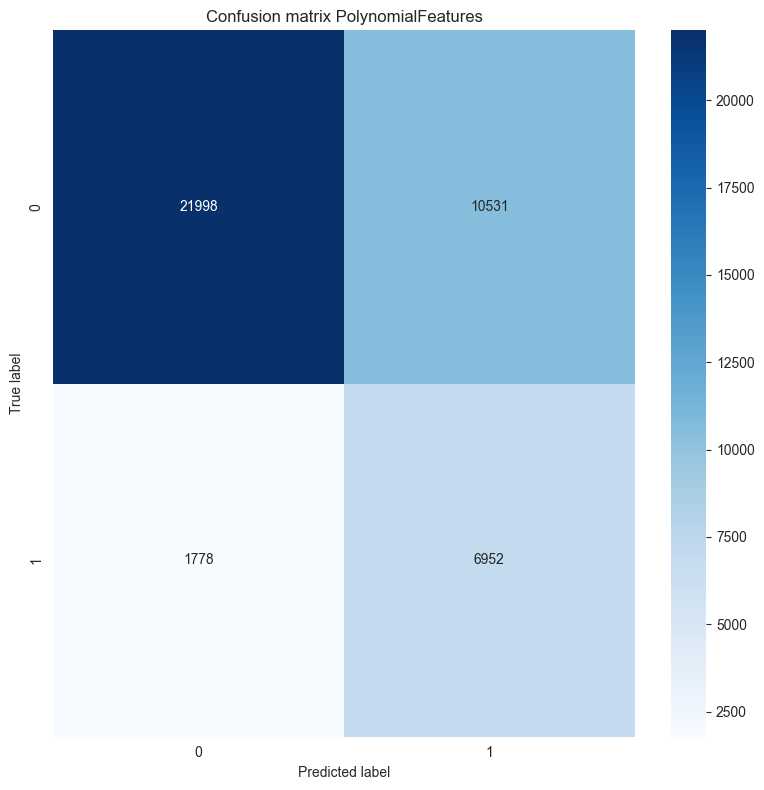

In [146]:
plot_confusion_matrix(y_test, y_pred_poly, "PolynomialFeatures")

#### Выводы: 
После добавления PolynomialFeatures метрики всё ещё не растут. Возможно нелинейные взаимодействия слабы, и логистическая регрессия достигает своего потолка
